# 06 — Hardware-aware QOS campaign 与 Quafu-SQC 实验包

本章把已经验证的 Boolean echo 变成一个**安全、可审计、默认不提交**的
Quafu-SQC campaign。它包含：

- H-only、exact-pair、balanced-stream、IID 四类主线路；
- 另加 compiler-stress 与去 barrier 的 optimized twin；
- $n=1,2$ 的主实验与 $n=3$ sparse 压力测试；
- 基于真实门级线路的 generic depolarizing + readout 仿真；
- 每条 QASM 的数据流、truth table、hash、门数与任务模板；
- Quafu-SQC 返回的 counts、corrected counts、transpiled QASM 的统一解析。

本章使用 `qiskit-aer` 的噪声只是**通用工程模型**，不是 Quafu-SQC
后端校准模型。
真机曲线只有在用户实际提交并取得设备返回后才存在。

若你对 $M$、$R_{\rm streams}$、$S_{\rm shots}$ 或 $j$ 仍不熟，请先看
`05` 开头的符号表。这里始终坚持：

```text
一次 sample update ≠ 一次 shot ≠ 一条独立 stream ≠ 一个云端 task
```


In [1]:
import hashlib
import json
import os
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import qasm2, transpile
from qiskit.circuit import Gate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
)

SEED = 20260729
S_SHOTS = 2048
R_NOISE_STREAMS = 30
NOISE_M_RATIOS = np.array([1, 2, 4, 8, 16])

P_1Q = 5e-4
P_2Q = 3e-3
P_READOUT = 1e-2
STABILITY_SELECTION_FREQUENCY = 0.80

bundle_root = Path("../results/quafu_bundle")
qasm_dir = bundle_root / "qasm"
raw_result_dir = bundle_root / "raw_results"
asset_figure_dir = Path("../assets/figures")
asset_circuit_dir = Path("../assets/circuits")
for directory in (
    bundle_root,
    qasm_dir,
    raw_result_dir,
    asset_figure_dir,
    asset_circuit_dir,
):
    directory.mkdir(parents=True, exist_ok=True)


## 1. 同一套 QASM 生成器

主 campaign 在每个有效样本 projector 后保留 barrier。这样编译器不容易把
相邻样本边界整体消去，便于研究“门数随有效样本增加”的工程代价。
另有少量 `optimized twin` 去掉 barrier，用于单独研究编译优化收益。

barrier 是编译提示/可视分隔，不是带物理作用的量子门；远端编译器仍可能
删除或跨越它优化。因此必须保存并检查返回的 transpiled QASM。

$n=3$ 每个有效 update 需要 4 个 CCX，成本会快速增长。因此它只进入
sparse marked 压力测试；是否扩大规模必须由真机返回的 transpiled
two-qubit count 与 depth 决定。

### 六类线路各自在排除什么

| 类型 | 它做什么 | 理想结果 | 若真机失败，先怀疑什么 |
|---|---|---|---|
| H-only | $H$、barrier、$H$ 后测量 | $F_{\rm echo}=1$ | 读出、编译器消门或最基础单比特门 |
| exact-pair | 精确 oracle 后立刻接精确 inverse | $F_{\rm echo}=1$ | projector 门合成、路由或深线路噪声 |
| balanced-depth | 每个地址出现同样多次，再接 inverse | $F_{\rm echo}=1$ | 门噪声；没有 IID 计数波动 |
| IID | 地址按 IID 随机到达 | 平均随 $M$ 改善 | 数据采样误差和门噪声共同作用 |
| compiler-stress | $n=3$ majority 的高 CCX 压力线路 | $F_{\rm echo}=1$ | 只测试离线解析/编译极限，不是首批真机任务 |
| optimized twin | 复用同一 balanced stream，只去掉 update barriers | 与配对线路相同 | 两者差异主要来自编译优化 |

`balanced-depth` 是历史内部名称。它匹配同一个 $M$ 和**平均门数尺度**，
并不与每一条 IID 流严格逐线路等深；正文称它为 balanced-stream control。


In [2]:
def truth_table(n_address, kind, seed=SEED):
    n_states = 2**n_address
    if kind == "parity":
        values = [x.bit_count() % 2 for x in range(n_states)]
    elif kind == "marked":
        values = [int(x == n_states - 1) for x in range(n_states)]
    elif kind == "majority":
        threshold = (n_address + 1) // 2
        values = [
            int(x.bit_count() >= threshold) for x in range(n_states)
        ]
    else:
        raise ValueError(f"Unknown function kind: {kind}")
    return np.asarray(values, dtype=np.int8)


def work_qubit_count(n_address):
    if n_address in (1, 2):
        return 1
    if n_address == 3:
        return 2
    raise NotImplementedError


def draw_stream(rng, n_states, m_data, mode):
    if mode == "iid":
        return rng.integers(0, n_states, size=m_data, dtype=np.int64)
    if mode == "balanced":
        if m_data % n_states:
            raise ValueError("Balanced stream requires M_data % N == 0.")
        stream = np.tile(np.arange(n_states), m_data // n_states)
        rng.shuffle(stream)
        return stream
    raise ValueError(f"Unknown stream mode: {mode}")


def append_projector_phase_qasm(
    lines,
    n_address,
    address,
    theta,
    preserve_update_boundary=True,
):
    zero_bits = [
        bit
        for bit in range(n_address)
        if ((address >> bit) & 1) == 0
    ]
    for bit in zero_bits:
        lines.append(f"x q[{bit}];")

    if n_address == 1:
        flag = 1
        lines.append("cx q[0],q[1];")
    elif n_address == 2:
        flag = 2
        lines.append("ccx q[0],q[1],q[2];")
    elif n_address == 3:
        work0, flag = 3, 4
        lines.append(f"ccx q[0],q[1],q[{work0}];")
        lines.append(f"ccx q[{work0}],q[2],q[{flag}];")
    else:
        raise NotImplementedError

    lines.append(f"u1({float(theta):.16g}) q[{flag}];")

    if n_address == 1:
        lines.append("cx q[0],q[1];")
    elif n_address == 2:
        lines.append("ccx q[0],q[1],q[2];")
    else:
        lines.append(f"ccx q[{work0}],q[2],q[{flag}];")
        lines.append(f"ccx q[0],q[1],q[{work0}];")

    for bit in reversed(zero_bits):
        lines.append(f"x q[{bit}];")
    if preserve_update_boundary:
        lines.append("barrier q;")


def qasm_header(n_address, with_work=True):
    n_total = (
        n_address + work_qubit_count(n_address)
        if with_work
        else n_address
    )
    return [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        f"qreg q[{n_total}];",
        f"creg c[{n_address}];",
    ]


def append_initial_h(lines, n_address):
    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
    lines.append("barrier q;")


def append_final_h_measure(lines, n_address):
    lines.append("barrier q;")
    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
        lines.append(f"measure q[{bit}] -> c[{bit}];")


def build_h_only_qasm(n_address):
    lines = qasm_header(n_address, with_work=False)
    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
    lines.append("barrier q;")
    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
        lines.append(f"measure q[{bit}] -> c[{bit}];")
    return "\n".join(lines) + "\n"


def build_exact_pair_qasm(
    f_values, preserve_update_boundaries=True
):
    f_values = np.asarray(f_values, dtype=np.int8)
    n_address = int(np.log2(len(f_values)))
    lines = qasm_header(n_address, with_work=True)
    append_initial_h(lines, n_address)
    for address, value in enumerate(f_values):
        if value:
            append_projector_phase_qasm(
                lines,
                n_address,
                address,
                np.pi,
                preserve_update_boundaries,
            )
    lines.append("barrier q;")
    for address, value in enumerate(f_values):
        if value:
            append_projector_phase_qasm(
                lines,
                n_address,
                address,
                -np.pi,
                preserve_update_boundaries,
            )
    append_final_h_measure(lines, n_address)
    return "\n".join(lines) + "\n"


def build_sampled_echo_qasm(
    f_values,
    stream,
    preserve_update_boundaries=True,
):
    f_values = np.asarray(f_values, dtype=np.int8)
    stream = np.asarray(stream, dtype=np.int64)
    n_states = len(f_values)
    n_address = int(np.log2(n_states))
    theta = np.pi * n_states / len(stream)
    lines = qasm_header(n_address, with_work=True)
    append_initial_h(lines, n_address)
    for address in stream:
        if f_values[address]:
            append_projector_phase_qasm(
                lines,
                n_address,
                int(address),
                theta,
                preserve_update_boundaries,
            )
    lines.append("barrier q;")
    for address, value in enumerate(f_values):
        if value:
            append_projector_phase_qasm(
                lines,
                n_address,
                address,
                -np.pi,
                preserve_update_boundaries,
            )
    append_final_h_measure(lines, n_address)
    return "\n".join(lines) + "\n"


def sampled_echo_fidelity(f_values, stream):
    f_values = np.asarray(f_values, dtype=np.int8)
    n_states = len(f_values)
    theta = np.pi * n_states / len(stream)
    counts = np.bincount(stream, minlength=n_states)
    residual = theta * counts * f_values - np.pi * f_values
    return float(abs(np.mean(np.exp(1j * residual))) ** 2)


def expected_physical_echo_fidelity(
    n_states, num_marked, m_data
):
    theta = np.pi * n_states / m_data
    a = (
        1 - 1 / n_states + np.exp(1j * theta) / n_states
    ) ** m_data
    b = (
        1 + 2 * (np.cos(theta) - 1) / n_states
    ) ** m_data
    unmarked = n_states - num_marked
    return float(
        (
            unmarked**2
            + num_marked
            + num_marked * (num_marked - 1) * b
            - 2 * num_marked * unmarked * np.real(a)
        )
        / n_states**2
    )


def stream_hash(stream):
    return hashlib.sha256(
        np.asarray(stream, dtype=np.int64).tobytes()
    ).hexdigest()


def text_hash(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


## 2. 生成离线实验包

manifest 同时保存：

- $R_{\rm streams}$、$M_{\rm data}$、$S_{\rm shots}$ 的角色；
- 完整 stream 与 stream hash；
- truth table 与 hash；
- QASM hash；
- 编译前 CX/CCX/depth；
- 把每个 CCX 粗略记作 6 个 CX 的 `CX proxy`。

`CX proxy` 只用于提交前筛选，不是远端真实二比特门数。60/180 两条线是
**本项目自定的保守筛选启发式**，不是 Quafu-SQC 的设备上限。真实数字必须
从 `result["transpiled"]` 重新解析。


In [3]:
bundle_specs = []

for n_address in (1, 2, 3):
    bundle_specs.append(
        {
            "control_type": "h_only",
            "n_address": n_address,
            "function": "none",
            "stream_mode": "none",
            "M_data": 0,
            "replicates": 1,
            "barriers": False,
        }
    )

for n_address, function_kind in (
    (1, "parity"),
    (2, "parity"),
    (3, "marked"),
):
    bundle_specs.append(
        {
            "control_type": "exact_pair",
            "n_address": n_address,
            "function": function_kind,
            "stream_mode": "none",
            "M_data": 0,
            "replicates": 1,
            "barriers": True,
        }
    )

bundle_specs.extend(
    [
        {
            "control_type": "balanced_depth",
            "n_address": 1,
            "function": "parity",
            "stream_mode": "balanced",
            "M_data": 8,
            "replicates": 1,
            "barriers": True,
        },
        {
            "control_type": "balanced_depth",
            "n_address": 2,
            "function": "parity",
            "stream_mode": "balanced",
            "M_data": 16,
            "replicates": 1,
            "barriers": True,
        },
        {
            "control_type": "balanced_depth",
            "n_address": 3,
            "function": "marked",
            "stream_mode": "balanced",
            "M_data": 16,
            "replicates": 1,
            "barriers": True,
        },
        {
            "control_type": "compiler_stress",
            "n_address": 3,
            "function": "majority",
            "stream_mode": "balanced",
            "M_data": 8,
            "replicates": 1,
            "barriers": True,
        },
    ]
)

for n_address, function_kind, m_values in (
    (1, "parity", (2, 4, 8, 16)),
    (2, "parity", (4, 8, 16, 32, 64)),
    (2, "marked", (8, 16, 32)),
    (3, "marked", (8, 16, 32)),
):
    for m_data in m_values:
        bundle_specs.append(
            {
                "control_type": "iid",
                "n_address": n_address,
                "function": function_kind,
                "stream_mode": "iid",
                "M_data": m_data,
                "replicates": 2,
                "barriers": True,
            }
        )

# Two optimized twins quantify what barriers cost without changing
# the main barrier-preserving campaign.
for n_address, m_data in ((1, 8), (2, 16)):
    bundle_specs.append(
        {
            "control_type": "optimized_twin",
            "n_address": n_address,
            "function": "parity",
            "stream_mode": "balanced",
            "M_data": m_data,
            "replicates": 1,
            "barriers": False,
        }
    )

bundle_rng = np.random.default_rng(SEED + 200)
manifest_entries = []
paired_streams = {}
experiment_counter = 0

for spec in bundle_specs:
    for replicate in range(spec["replicates"]):
        experiment_counter += 1
        n_address = spec["n_address"]
        n_states = 2**n_address
        function_kind = spec["function"]
        pair_id = ""
        if (
            spec["control_type"]
            in {"balanced_depth", "optimized_twin"}
            and (n_address, spec["M_data"]) in {(1, 8), (2, 16)}
        ):
            pair_id = (
                f"barrier_pair_n{n_address}_"
                f"{function_kind}_M{spec['M_data']}"
            )

        if spec["control_type"] == "h_only":
            f_values = np.zeros(n_states, dtype=np.int8)
            stream = np.asarray([], dtype=np.int64)
            qasm_text = build_h_only_qasm(n_address)
            ideal_fidelity = 1.0
        else:
            f_values = truth_table(n_address, function_kind)
            if spec["control_type"] == "exact_pair":
                stream = np.asarray([], dtype=np.int64)
                qasm_text = build_exact_pair_qasm(
                    f_values,
                    preserve_update_boundaries=spec["barriers"],
                )
                ideal_fidelity = 1.0
            else:
                if spec["control_type"] == "optimized_twin":
                    if pair_id not in paired_streams:
                        raise AssertionError(
                            "Paired balanced stream was not generated first."
                        )
                    stream = paired_streams[pair_id].copy()
                else:
                    stream = draw_stream(
                        bundle_rng,
                        n_states,
                        spec["M_data"],
                        spec["stream_mode"],
                    )
                    if pair_id:
                        paired_streams[pair_id] = stream.copy()
                qasm_text = build_sampled_echo_qasm(
                    f_values,
                    stream,
                    preserve_update_boundaries=spec["barriers"],
                )
                ideal_fidelity = sampled_echo_fidelity(
                    f_values, stream
                )

        circuit = qasm2.loads(qasm_text)
        ops = dict(circuit.count_ops())
        cx_proxy = int(ops.get("cx", 0) + 6 * ops.get("ccx", 0))
        if cx_proxy <= 60:
            budget_tier = "low"
        elif cx_proxy <= 180:
            budget_tier = "medium"
        else:
            budget_tier = "high"

        experiment_id = (
            f"qos_{experiment_counter:03d}_"
            f"{spec['control_type']}_n{n_address}_"
            f"M{spec['M_data']}_r{replicate}"
        )
        qasm_path = qasm_dir / f"{experiment_id}.qasm"
        qasm_path_project_relative = (
            Path("results")
            / "quafu_bundle"
            / "qasm"
            / f"{experiment_id}.qasm"
        )
        qasm_path.write_text(qasm_text, encoding="utf-8")

        task_template = {
            "chip": "Baihua",
            "name": experiment_id,
            "circuit_file": str(qasm_path_project_relative),
            "shots": S_SHOTS,
            "compile": True,
            "options": {
                "compiler": "quarkcircuit",
                "correct": False,
                "open_dd": None,
                "target_qubits": [],
            },
        }

        manifest_entries.append(
            {
                "experiment_id": experiment_id,
                "control_type": spec["control_type"],
                "n_address": n_address,
                "n_total_qubits": circuit.num_qubits,
                "N": n_states,
                "function": function_kind,
                "truth_table": f_values.tolist(),
                "truth_table_sha256": text_hash(
                    json.dumps(f_values.tolist())
                ),
                "stream_mode": spec["stream_mode"],
                "stream": stream.tolist(),
                "stream_sha256": stream_hash(stream),
                "M_data": int(spec["M_data"]),
                "R_streams": int(spec["replicates"]),
                "R_stream_index": replicate,
                "S_shots": S_SHOTS,
                "pair_id": pair_id,
                "preserve_update_boundaries": spec["barriers"],
                "ideal_F_echo": ideal_fidelity,
                "qasm_path": str(qasm_path_project_relative),
                "qasm_sha256": text_hash(qasm_text),
                "logical_depth": circuit.depth(),
                "logical_h": int(ops.get("h", 0)),
                "logical_x": int(ops.get("x", 0)),
                "logical_cx": int(ops.get("cx", 0)),
                "logical_ccx": int(ops.get("ccx", 0)),
                "logical_u1": int(ops.get("u1", 0)),
                "cx_proxy_before_routing": cx_proxy,
                "budget_tier": budget_tier,
                "recommended_first_pilot": (
                    budget_tier == "low"
                    and spec["control_type"]
                    in {"h_only", "balanced_depth"}
                ),
                "task_template": task_template,
            }
        )

manifest_path = bundle_root / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest_entries, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

manifest_frame = pd.DataFrame(
    [
        {
            key: value
            for key, value in entry.items()
            if key not in {"stream", "truth_table", "task_template"}
        }
        for entry in manifest_entries
    ]
)
manifest_csv_path = bundle_root / "manifest.csv"
manifest_frame.to_csv(manifest_csv_path, index=False)

parsed_qasm_count = sum(
    qasm2.loads(
        (Path("..") / entry["qasm_path"]).read_text(
            encoding="utf-8"
        )
    )
    is not None
    for entry in manifest_entries
)
assert parsed_qasm_count == len(manifest_entries)
assert np.all(
    manifest_frame.loc[
        manifest_frame["stream_mode"] == "balanced",
        "ideal_F_echo",
    ].sub(1).abs()
    < 1e-10
)
for pair_id in sorted(paired_streams):
    pair_entries = [
        entry
        for entry in manifest_entries
        if entry["pair_id"] == pair_id
    ]
    assert {entry["control_type"] for entry in pair_entries} == {
        "balanced_depth",
        "optimized_twin",
    }
    assert len({entry["stream_sha256"] for entry in pair_entries}) == 1
    qasm_without_barriers = {
        "\n".join(
            line
            for line in (
                Path("..") / entry["qasm_path"]
            ).read_text(encoding="utf-8").splitlines()
            if not line.startswith("barrier ")
        )
        for entry in pair_entries
    }
    assert len(qasm_without_barriers) == 1

print("Generated QASM files:", len(manifest_entries))
print("All parsed successfully:", parsed_qasm_count)
print("Manifest:", manifest_path)
display(
    manifest_frame[
        [
            "experiment_id",
            "control_type",
            "n_address",
            "function",
            "M_data",
            "ideal_F_echo",
            "logical_ccx",
            "cx_proxy_before_routing",
            "budget_tier",
            "recommended_first_pilot",
        ]
    ].head(12)
)


Generated QASM files: 42
All parsed successfully: 42
Manifest: ../results/quafu_bundle/manifest.json


,experiment_id,control_type,n_address,function,M_data,ideal_F_echo,logical_ccx,cx_proxy_before_routing,budget_tier,recommended_first_pilot
0,qos_001_h_only_n1_M0_r0,h_only,1,none,0,1.000000e+00,0,0,low,True
1,qos_002_h_only_n2_M0_r0,h_only,2,none,0,1.000000e+00,0,0,low,True
2,qos_003_h_only_n3_M0_r0,h_only,3,none,0,1.000000e+00,0,0,low,True
3,qos_004_exact_pair_n1_M0_r0,exact_pair,1,parity,0,1.000000e+00,0,4,low,False
4,qos_005_exact_pair_n2_M0_r0,exact_pair,2,parity,0,1.000000e+00,8,48,low,False
5,qos_006_exact_pair_n3_M0_r0,exact_pair,3,marked,0,1.000000e+00,8,48,low,False
6,qos_007_balanced_depth_n1_M8_r0,balanced_depth,1,parity,8,1.000000e+00,0,10,low,True
7,qos_008_balanced_depth_n2_M16_r0,balanced_depth,2,parity,16,1.000000e+00,20,120,medium,False
8,qos_009_balanced_depth_n3_M16_r0,balanced_depth,3,marked,16,1.000000e+00,12,72,medium,False
9,qos_010_compiler_stress_n3_M8_r0,compiler_stress,3,majority,8,1.000000e+00,32,192,high,False


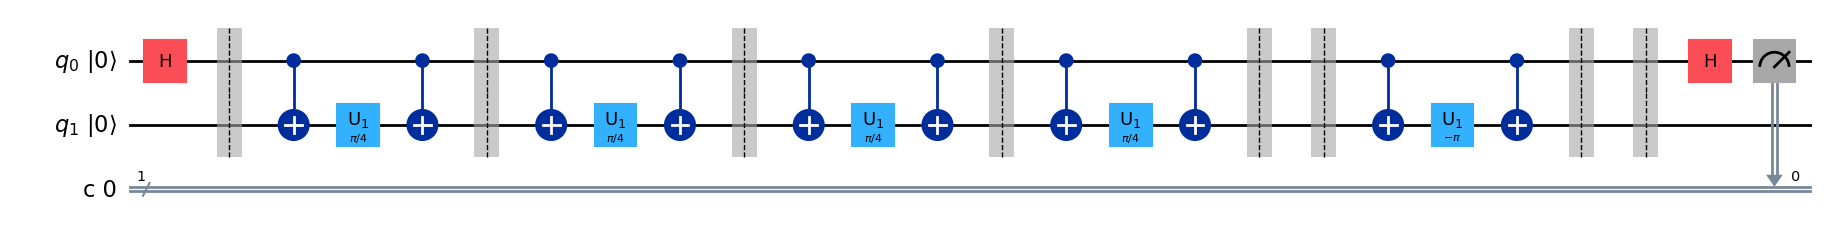

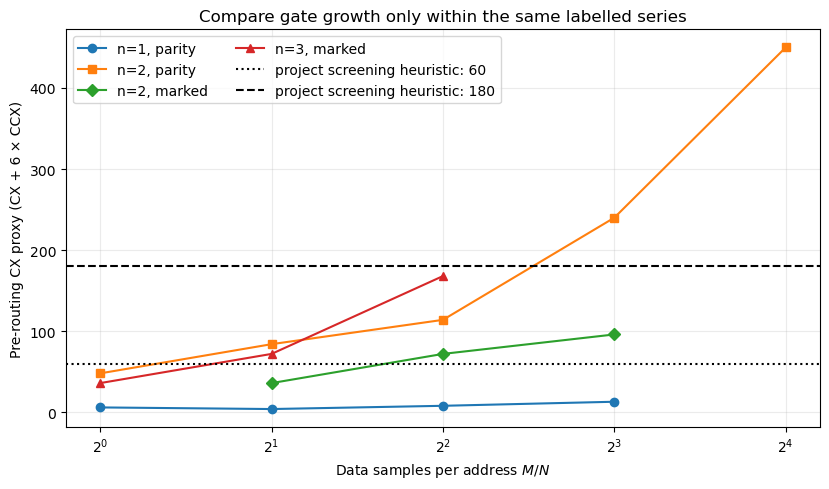

Saved: ../assets/circuits/qos-campaign-balanced-n1.png
Saved: ../assets/figures/qos-gate-pressure.png


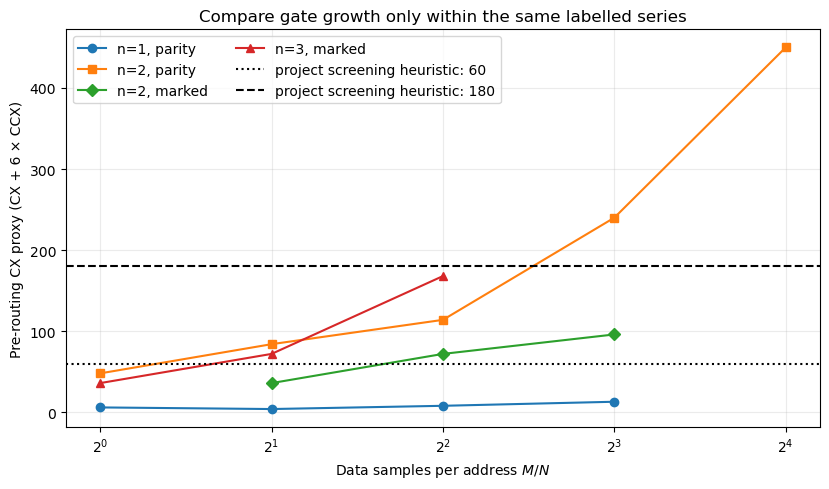

In [4]:
representative_entry = next(
    entry
    for entry in manifest_entries
    if entry["control_type"] == "balanced_depth"
    and entry["n_address"] == 1
)
representative_circuit = qasm2.loads(
    (Path("..") / representative_entry["qasm_path"]).read_text(
        encoding="utf-8"
    )
)
representative_figure = representative_circuit.draw(
    output="mpl",
    fold=38,
    idle_wires=False,
    initial_state=True,
)
representative_path = (
    asset_circuit_dir / "qos-campaign-balanced-n1.png"
)
representative_figure.savefig(
    representative_path, dpi=180, bbox_inches="tight"
)
display(representative_figure)

resource_subset = (
    manifest_frame[manifest_frame["control_type"] == "iid"]
    .groupby(
        ["n_address", "function", "N", "M_data"],
        as_index=False,
    )["cx_proxy_before_routing"]
    .mean()
)
fig, ax = plt.subplots(figsize=(8.4, 5.0))
series_styles = {
    (1, "parity"): "o",
    (2, "parity"): "s",
    (2, "marked"): "D",
    (3, "marked"): "^",
}
for (n_address, function_kind), marker in series_styles.items():
    subset = resource_subset[
        (resource_subset["n_address"] == n_address)
        & (resource_subset["function"] == function_kind)
    ].sort_values("M_data")
    ax.plot(
        subset["M_data"] / subset["N"],
        subset["cx_proxy_before_routing"],
        marker=marker,
        label=f"n={n_address}, {function_kind}",
    )
ax.axhline(
    60,
    color="black",
    linestyle=":",
    label="project screening heuristic: 60",
)
ax.axhline(
    180,
    color="black",
    linestyle="--",
    label="project screening heuristic: 180",
)
ax.set_xscale("log", base=2)
ax.set(
    xlabel=r"Data samples per address $M/N$",
    ylabel="Pre-routing CX proxy (CX + 6 × CCX)",
    title="Compare gate growth only within the same labelled series",
)
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()
resource_path = asset_figure_dir / "qos-gate-pressure.png"
fig.savefig(resource_path, dpi=180, bbox_inches="tight")
display(fig)

print("Saved:", representative_path)
print("Saved:", resource_path)


## 3. Generic gate-level noise：采样收益与门噪声竞争

这里固定 $n=2$ parity，扫描 $M/N$。每个 IID 点使用
`R_NOISE_STREAMS` 条独立数据流；每条流是一条不同的 QASM。

对照包含：

- 解析的理想 IID 平均；
- 无噪 QASM statevector；
- generic noise 下的 IID 线路；
- 相同 $M$、匹配平均门数尺度的 balanced-stream control。

balanced-stream control 在理想情况下严格 $F_{\rm echo}=1$，因此它随
$M$ 下降
只能来自这套通用门噪声和 finite shots，而不是数据采样误差。

`depolarizing_error()` 的参数是 Qiskit 的 depolarizing parameter
$\lambda$，不是后端校准报告中的平均门错误率。该模型不包含设备 topology、
routing、idle noise、$T_1/T_2$、coherent error、crosstalk 或 drift；
barrier 在模型中也没有物理时长。


In [5]:
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(P_1Q, 1), ["u"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(P_2Q, 2), ["cx"]
)
noise_model.add_all_qubit_readout_error(
    ReadoutError(
        [
            [1 - P_READOUT, P_READOUT],
            [P_READOUT, 1 - P_READOUT],
        ]
    )
)
noisy_simulator = AerSimulator(noise_model=noise_model)

noise_rng = np.random.default_rng(SEED + 400)
f_values = truth_table(2, "parity")
n_states = len(f_values)
noisy_circuits = []
noisy_metadata = []
balanced_circuits = []
balanced_metadata = []

for ratio in NOISE_M_RATIOS:
    m_data = int(ratio * n_states)
    for stream_index in range(R_NOISE_STREAMS):
        stream = draw_stream(
            noise_rng, n_states, m_data, mode="iid"
        )
        qasm_text = build_sampled_echo_qasm(
            f_values,
            stream,
            preserve_update_boundaries=True,
        )
        circuit = qasm2.loads(qasm_text)
        bare = circuit.remove_final_measurements(inplace=False)
        statevector = Statevector.from_instruction(bare)
        exact_qasm_fidelity = float(
            abs(statevector.data[0]) ** 2
        )
        direct_fidelity = sampled_echo_fidelity(
            f_values, stream
        )
        assert abs(exact_qasm_fidelity - direct_fidelity) < 1e-10

        basis_circuit = transpile(
            circuit,
            basis_gates=["u", "cx"],
            optimization_level=0,
        )
        noisy_circuits.append(basis_circuit)
        noisy_metadata.append(
            {
                "M_over_N": int(ratio),
                "M_data": m_data,
                "stream_index": stream_index,
                "ideal_F_echo": direct_fidelity,
                "transpiled_depth_local": basis_circuit.depth(),
                "local_cx_count": int(
                    basis_circuit.count_ops().get("cx", 0)
                ),
            }
        )

    balanced_stream = draw_stream(
        noise_rng, n_states, m_data, mode="balanced"
    )
    balanced_qasm = build_sampled_echo_qasm(
        f_values,
        balanced_stream,
        preserve_update_boundaries=True,
    )
    balanced_circuit = transpile(
        qasm2.loads(balanced_qasm),
        basis_gates=["u", "cx"],
        optimization_level=0,
    )
    balanced_circuits.append(balanced_circuit)
    balanced_metadata.append(
        {
            "M_over_N": int(ratio),
            "M_data": m_data,
            "local_cx_count": int(
                balanced_circuit.count_ops().get("cx", 0)
            ),
            "transpiled_depth_local": balanced_circuit.depth(),
        }
    )

noisy_result = noisy_simulator.run(
    noisy_circuits,
    shots=S_SHOTS,
    seed_simulator=SEED + 500,
).result()
balanced_result = noisy_simulator.run(
    balanced_circuits,
    shots=S_SHOTS,
    seed_simulator=SEED + 501,
).result()

noisy_rows = []
for index, metadata in enumerate(noisy_metadata):
    counts = noisy_result.get_counts(index)
    observed = counts.get("00", 0) / S_SHOTS
    noisy_rows.append(
        {
            **metadata,
            "generic_noise_F_echo": observed,
            "shot_ci95_halfwidth": 1.96
            * np.sqrt(observed * (1 - observed) / S_SHOTS),
            "counts": json.dumps(counts, sort_keys=True),
        }
    )
noisy_streams = pd.DataFrame(noisy_rows)

balanced_rows = []
for index, metadata in enumerate(balanced_metadata):
    counts = balanced_result.get_counts(index)
    observed = counts.get("00", 0) / S_SHOTS
    balanced_rows.append(
        {
            **metadata,
            "generic_noise_F_echo": observed,
            "shot_ci95_halfwidth": 1.96
            * np.sqrt(observed * (1 - observed) / S_SHOTS),
            "counts": json.dumps(counts, sort_keys=True),
        }
    )
balanced_controls = pd.DataFrame(balanced_rows)

display(noisy_streams.head())
display(balanced_controls)


,M_over_N,M_data,stream_index,ideal_F_echo,transpiled_depth_local,local_cx_count,generic_noise_F_echo,shot_ci95_halfwidth,counts
0,1,4,0,3.749399e-33,49,24,0.016602,0.005534,"{""00"": 34, ""01"": 70, ""10"": 71, ""11"": 1873}"
1,1,4,1,0.000000e+00,95,48,0.036133,0.008083,"{""00"": 74, ""01"": 92, ""10"": 105, ""11"": 1777}"
2,1,4,2,2.500000e-01,118,60,0.249512,0.018742,"{""00"": 511, ""01"": 479, ""10"": 528, ""11"": 530}"
3,1,4,3,2.500000e-01,118,60,0.258789,0.018969,"{""00"": 530, ""01"": 492, ""10"": 514, ""11"": 512}"
4,1,4,4,3.749399e-33,49,24,0.017090,0.005613,"{""00"": 35, ""01"": 58, ""10"": 61, ""11"": 1894}"


,M_over_N,M_data,local_cx_count,transpiled_depth_local,generic_noise_F_echo,shot_ci95_halfwidth,counts
0,1,4,48,95,0.868652,0.014629,"{""00"": 1779, ""01"": 105, ""10"": 98, ""11"": 66}"
1,2,8,72,141,0.817383,0.016733,"{""00"": 1674, ""01"": 138, ""10"": 140, ""11"": 96}"
2,4,16,120,233,0.734375,0.019129,"{""00"": 1504, ""01"": 189, ""10"": 168, ""11"": 187}"
3,8,32,216,417,0.583984,0.021347,"{""00"": 1196, ""01"": 281, ""10"": 290, ""11"": 281}"
4,16,64,408,785,0.419922,0.021376,"{""00"": 860, ""01"": 379, ""10"": 397, ""11"": 412}"


In [6]:
grouped_rows = []
for ratio, group in noisy_streams.groupby("M_over_N"):
    m_data = int(group["M_data"].iloc[0])
    grouped_rows.append(
        {
            "M_over_N": int(ratio),
            "M_data": m_data,
            "R_streams": len(group),
            "S_shots": S_SHOTS,
            "analytic_ideal_F": expected_physical_echo_fidelity(
                n_states, int(f_values.sum()), m_data
            ),
            "mean_noiseless_QASM_F": group[
                "ideal_F_echo"
            ].mean(),
            "noiseless_QASM_approx_normal_ci95_halfwidth": 1.96
            * group["ideal_F_echo"].std(ddof=1)
            / np.sqrt(len(group)),
            "mean_generic_noise_F": group[
                "generic_noise_F_echo"
            ].mean(),
            "generic_noise_approx_normal_ci95_halfwidth": 1.96
            * group["generic_noise_F_echo"].std(ddof=1)
            / np.sqrt(len(group)),
            "mean_local_cx_count": group[
                "local_cx_count"
            ].mean(),
        }
    )

noise_summary = pd.DataFrame(grouped_rows).sort_values("M_over_N")
noise_summary = noise_summary.merge(
    balanced_controls[
        [
            "M_over_N",
            "generic_noise_F_echo",
            "shot_ci95_halfwidth",
        ]
    ].rename(
        columns={
            "generic_noise_F_echo": "balanced_generic_noise_F",
            "shot_ci95_halfwidth": (
                "balanced_shot_approx_normal_ci95_halfwidth"
            ),
        }
    ),
    on="M_over_N",
    how="left",
)
display(noise_summary)

bootstrap_rng = np.random.default_rng(SEED + 600)
bootstrap_choices = []
bootstrap_repeats = 1200
ratio_values = noise_summary["M_over_N"].to_numpy()
for _ in range(bootstrap_repeats):
    mean_errors = []
    for ratio in ratio_values:
        values = noisy_streams.loc[
            noisy_streams["M_over_N"] == ratio,
            "generic_noise_F_echo",
        ].to_numpy()
        resampled = bootstrap_rng.choice(
            values, size=len(values), replace=True
        )
        mean_errors.append(1 - resampled.mean())
    bootstrap_choices.append(
        int(ratio_values[int(np.argmin(mean_errors))])
    )

optimum_support = (
    pd.Series(bootstrap_choices)
    .value_counts(normalize=True)
    .reindex(ratio_values, fill_value=0.0)
    .rename_axis("M_over_N")
    .rename("bootstrap_selection_frequency")
    .reset_index()
)
display(optimum_support)

best_row = optimum_support.loc[
    optimum_support["bootstrap_selection_frequency"].idxmax()
]
stable_internal_optimum = (
    best_row["bootstrap_selection_frequency"]
    >= STABILITY_SELECTION_FREQUENCY
    and best_row["M_over_N"] not in {ratio_values.min(), ratio_values.max()}
)
if stable_internal_optimum:
    print(
        "Illustrative generic-noise optimum:",
        f"M/N={int(best_row['M_over_N'])}",
        "with bootstrap selection frequency "
        f"{best_row['bootstrap_selection_frequency']:.1%}",
    )
else:
    print(
        "No stable internal optimum under the predeclared "
        f"{STABILITY_SELECTION_FREQUENCY:.0%} selection-frequency "
        "heuristic; report the full curve.",
        dict(best_row),
    )


,M_over_N,M_data,R_streams,S_shots,analytic_ideal_F,mean_noiseless_QASM_F,noiseless_QASM_approx_normal_ci95_halfwidth,mean_generic_noise_F,generic_noise_approx_normal_ci95_halfwidth,mean_local_cx_count,balanced_generic_noise_F,balanced_shot_approx_normal_ci95_halfwidth
0,1,4,30,2048,0.343750,0.316667,0.130667,0.302132,0.109423,48.8,0.868652,0.014629
1,2,8,30,2048,0.439819,0.529167,0.119034,0.460645,0.091139,70.0,0.817383,0.016733
2,4,16,30,2048,0.580483,0.516335,0.102878,0.418311,0.064921,119.6,0.734375,0.019129
3,8,32,30,2048,0.725545,0.755171,0.071628,0.482080,0.034990,218.0,0.583984,0.021347
4,16,64,30,2048,0.839083,0.880991,0.043767,0.400407,0.011161,406.0,0.419922,0.021376


,M_over_N,bootstrap_selection_frequency
0,1,0.000833
1,2,0.324167
2,4,0.030833
3,8,0.644167
4,16,0.000000


No stable internal optimum under the predeclared 80% selection-frequency heuristic; report the full curve. {'M_over_N': np.float64(8.0), 'bootstrap_selection_frequency': np.float64(0.6441666666666667)}


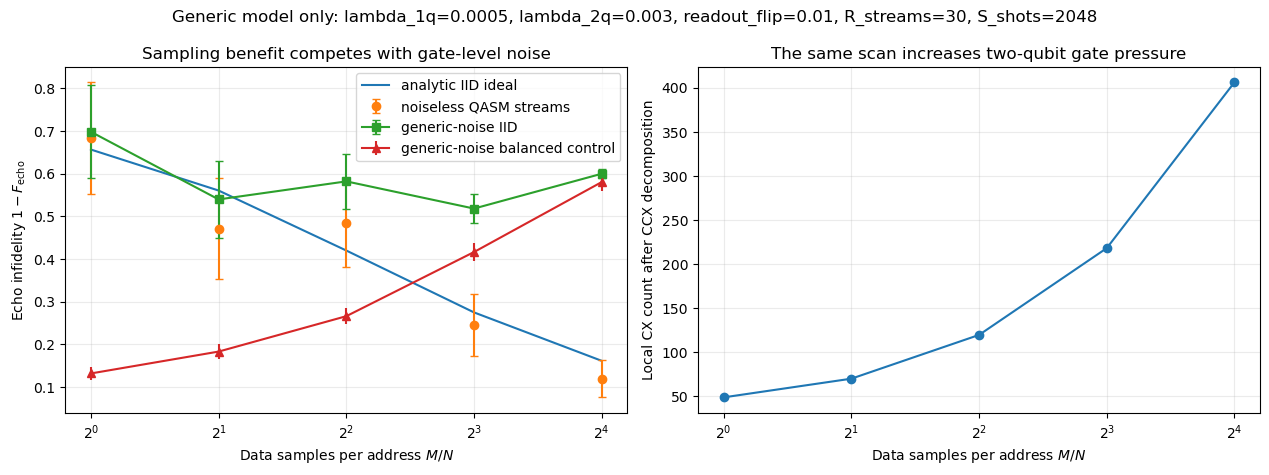

Saved: ../assets/figures/hardware-aware-qos-tradeoff.png
Saved: ../results/quafu_bundle/generic_noise_config.json


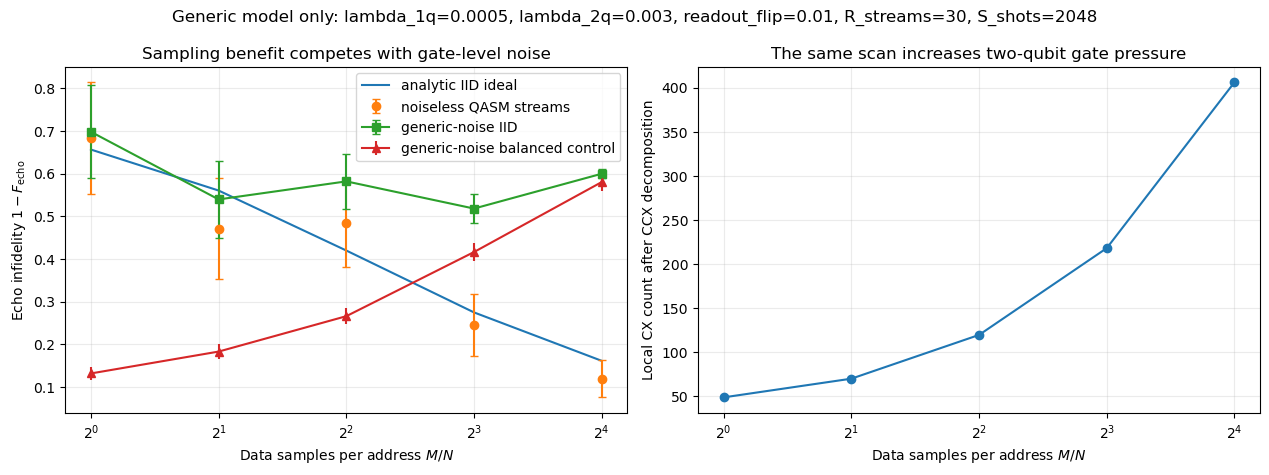

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

axes[0].plot(
    noise_summary["M_over_N"],
    1 - noise_summary["analytic_ideal_F"],
    label="analytic IID ideal",
)
axes[0].errorbar(
    noise_summary["M_over_N"],
    1 - noise_summary["mean_noiseless_QASM_F"],
    yerr=noise_summary[
        "noiseless_QASM_approx_normal_ci95_halfwidth"
    ],
    marker="o",
    capsize=3,
    linestyle="none",
    label="noiseless QASM streams",
)
axes[0].errorbar(
    noise_summary["M_over_N"],
    1 - noise_summary["mean_generic_noise_F"],
    yerr=noise_summary[
        "generic_noise_approx_normal_ci95_halfwidth"
    ],
    marker="s",
    capsize=3,
    label="generic-noise IID",
)
axes[0].errorbar(
    noise_summary["M_over_N"],
    1 - noise_summary["balanced_generic_noise_F"],
    yerr=noise_summary[
        "balanced_shot_approx_normal_ci95_halfwidth"
    ],
    marker="^",
    label="generic-noise balanced control",
)
axes[0].set_xscale("log", base=2)
axes[0].set(
    xlabel=r"Data samples per address $M/N$",
    ylabel=r"Echo infidelity $1-F_{\rm echo}$",
    title="Sampling benefit competes with gate-level noise",
)
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(
    noise_summary["M_over_N"],
    noise_summary["mean_local_cx_count"],
    marker="o",
)
axes[1].set_xscale("log", base=2)
axes[1].set(
    xlabel=r"Data samples per address $M/N$",
    ylabel="Local CX count after CCX decomposition",
    title="The same scan increases two-qubit gate pressure",
)
axes[1].grid(True, alpha=0.25)

fig.suptitle(
    "Generic model only: "
    f"lambda_1q={P_1Q:g}, lambda_2q={P_2Q:g}, "
    f"readout_flip={P_READOUT:g}, "
    f"R_streams={R_NOISE_STREAMS}, S_shots={S_SHOTS}"
)
fig.tight_layout()
tradeoff_path = (
    asset_figure_dir / "hardware-aware-qos-tradeoff.png"
)
fig.savefig(tradeoff_path, dpi=180, bbox_inches="tight")
display(fig)
print("Saved:", tradeoff_path)

noisy_streams.to_csv(
    bundle_root / "generic_noise_streams.csv", index=False
)
balanced_controls.to_csv(
    bundle_root / "generic_noise_balanced_controls.csv",
    index=False,
)
noise_summary.to_csv(
    bundle_root / "generic_noise_summary.csv", index=False
)
optimum_support.to_csv(
    bundle_root / "generic_noise_optimum_support.csv",
    index=False,
)

noise_config = {
    "seed": SEED,
    "n_address": 2,
    "function": "parity",
    "R_streams": R_NOISE_STREAMS,
    "S_shots": S_SHOTS,
    "M_over_N_grid": NOISE_M_RATIOS.tolist(),
    "qiskit_depolarizing_lambda_1q": P_1Q,
    "qiskit_depolarizing_lambda_2q": P_2Q,
    "symmetric_readout_flip_probability": P_READOUT,
    "bootstrap_repeats": bootstrap_repeats,
    "stability_selection_frequency_heuristic": (
        STABILITY_SELECTION_FREQUENCY
    ),
}
noise_config_path = bundle_root / "generic_noise_config.json"
noise_config_path.write_text(
    json.dumps(noise_config, indent=2),
    encoding="utf-8",
)
print("Saved:", noise_config_path)


读图时先看三点：

1. 左图纵轴是 $1-F_{\rm echo}$，所以**越低越好**；
2. 横轴使用以 2 为底的对数刻度，每向右一格代表 $M/N$ 翻倍；
3. IID 误差棒是跨 $R_{\rm streams}=30$ 条独立流的近似 95% 均值区间
   半宽；每条流本身又用 $S_{\rm shots}=2048$ 次测量估计。

bootstrap 数字是“重新抽取这些 IID stream 后，哪个网格点成为样本均值
最优点的频率”，不是“该点是真实最优的概率”。80% 只是本项目预先规定的
筛选启发式，不是统计置信水平；本轮没有达到它，所以只报告整条曲线。


## 4. Quafu-SQC 任务模板：默认关闭

本项目锁定并验证的是 `quafusqc==3.3.9`：

```python
from quafu import Task
```

当前官方 Quafu-SQC 文档仍接受完整 OpenQASM 2.0，并支持
`quarkcircuit | qsteed | qiskit` 编译器选项。这里不预先断言哪个编译器
最好：先用一条代表线路 A/B 比较 `quarkcircuit` 与 `qsteed` 的
transpiled two-qubit count/depth，再固定主 campaign 编译器。

为防止误提交：

- `SUBMIT_TO_HARDWARE=False`；
- 必须手工填入一个 `SELECTED_EXPERIMENT_ID`；
- 每次只提交一个任务；
- token 只从环境变量或隐藏输入读取。


In [8]:
BACKEND = "Baihua"
COMPILER = "quarkcircuit"
SUBMIT_TO_HARDWARE = False
SELECTED_EXPERIMENT_ID = None

selected_entry = None
if SELECTED_EXPERIMENT_ID is not None:
    selected_entry = next(
        (
            entry
            for entry in manifest_entries
            if entry["experiment_id"]
            == SELECTED_EXPERIMENT_ID
        ),
        None,
    )
    if selected_entry is None:
        raise ValueError("Experiment id is not in the manifest.")

if SUBMIT_TO_HARDWARE:
    if selected_entry is None:
        raise ValueError(
            "Set SELECTED_EXPERIMENT_ID before enabling submission."
        )
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    live_status = task_manager.status()
    print("Live backend status:", live_status)
    if live_status.get(BACKEND) in {"Offline", "Maintenance"}:
        raise RuntimeError(f"{BACKEND} is not currently available.")

    selected_qasm = (
        Path("..") / selected_entry["qasm_path"]
    ).read_text(encoding="utf-8")
    task = {
        "chip": BACKEND,
        "name": selected_entry["experiment_id"],
        "circuit": selected_qasm,
        "shots": selected_entry["S_shots"],
        "compile": True,
        "options": {
            "compiler": COMPILER,
            "correct": False,
            "open_dd": None,
            "target_qubits": [],
        },
    }
    submitted_task_id = task_manager.run(task)
    print("Submitted one task:", submitted_task_id)
else:
    print("Hardware submission disabled.")


Hardware submission disabled.


## 5. 统一解析 raw / corrected / transpiled

真实结果应同时保存：

- `count`：原始 counts；
- `corrected`：若开启 readout correction；
- `transpiled`：真正运行的 QASM；
- task id、compiler、DD、target qubits、时间与完整原始 JSON。

二比特门统计只数真正的 Qiskit `Gate`，不会把作用在多根线上的 barrier
或 delay 误计为量子门；同时单独报告残留的三比特及以上 gate。只有后者为
0 时，二比特门总数才足以描述已完成分解的主要纠缠门成本。

下面先用一个 mock result 验证解析器；它不是硬件数据。


In [9]:
def probability_zero(counts, n_address):
    if not counts:
        return np.nan
    total = float(sum(counts.values()))
    if total <= 0:
        return np.nan
    return float(counts.get("0" * n_address, 0) / total)


def transpiled_metrics(qasm_text):
    if not qasm_text:
        return {
            "transpiled_depth": np.nan,
            "transpiled_two_qubit_gates": np.nan,
            "transpiled_two_qubit_depth": np.nan,
            "transpiled_three_plus_qubit_gates": np.nan,
            "transpiled_swap": np.nan,
            "transpiled_ops": {},
        }
    circuit = qasm2.loads(qasm_text)
    gate_instructions = [
        instruction
        for instruction in circuit.data
        if isinstance(instruction.operation, Gate)
    ]
    two_qubit_count = sum(
        instruction.operation.num_qubits == 2
        for instruction in gate_instructions
    )
    three_plus_count = sum(
        instruction.operation.num_qubits >= 3
        for instruction in gate_instructions
    )
    two_qubit_depth = circuit.depth(
        filter_function=lambda instruction: (
            isinstance(instruction.operation, Gate)
            and instruction.operation.num_qubits == 2
        )
    )
    ops = dict(circuit.count_ops())
    return {
        "transpiled_depth": circuit.depth(),
        "transpiled_two_qubit_gates": int(two_qubit_count),
        "transpiled_two_qubit_depth": int(two_qubit_depth),
        "transpiled_three_plus_qubit_gates": int(
            three_plus_count
        ),
        "transpiled_swap": int(ops.get("swap", 0)),
        "transpiled_ops": ops,
    }


def parse_quafu_result(result, n_address):
    raw_counts = result.get("count") or {}
    corrected_counts = result.get("corrected") or {}
    metrics = transpiled_metrics(result.get("transpiled", ""))
    return {
        "tid": result.get("tid"),
        "status": result.get("status"),
        "raw_F_echo": probability_zero(
            raw_counts, n_address
        ),
        "corrected_F_echo": probability_zero(
            corrected_counts, n_address
        ),
        "finished": result.get("finished"),
        "error": result.get("error", ""),
        **metrics,
    }


mock_transpiled = build_h_only_qasm(2)
mock_result = {
    "count": {"00": 1000, "01": 8, "10": 8, "11": 8},
    "corrected": {},
    "transpiled": mock_transpiled,
    "status": "Finished",
    "tid": 0,
    "finished": "mock-only",
    "error": "",
}
parsed_mock = parse_quafu_result(mock_result, n_address=2)
display(pd.Series(parsed_mock, name="mock value").to_frame())
assert np.isclose(parsed_mock["raw_F_echo"], 1000 / 1024)
assert parsed_mock["transpiled_two_qubit_gates"] == 0
assert parsed_mock["transpiled_three_plus_qubit_gates"] == 0
print("Mock parser validation passed; this is not hardware data.")


,mock value
tid,0
status,Finished
raw_F_echo,0.976562
corrected_F_echo,NaN
finished,mock-only
error,
transpiled_depth,3
transpiled_two_qubit_gates,0
transpiled_two_qubit_depth,0
transpiled_three_plus_qubit_gates,0


Mock parser validation passed; this is not hardware data.


In [10]:
RESULT_TASK_IDS = {}
FETCH_REAL_RESULTS = False

if FETCH_REAL_RESULTS:
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    parsed_real_rows = []

    for experiment_id, task_id in RESULT_TASK_IDS.items():
        entry = next(
            item
            for item in manifest_entries
            if item["experiment_id"] == experiment_id
        )
        result = task_manager.result(int(task_id), timeout=60)
        raw_path = raw_result_dir / f"{experiment_id}_{task_id}.json"
        raw_path.write_text(
            json.dumps(result, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        parsed_real_rows.append(
            {
                "experiment_id": experiment_id,
                "task_id": int(task_id),
                **parse_quafu_result(
                    result, entry["n_address"]
                ),
            }
        )

    parsed_real_results = pd.DataFrame(parsed_real_rows)
    display(parsed_real_results)
    parsed_real_results.to_csv(
        bundle_root / "parsed_real_results.csv", index=False
    )
else:
    print("Real-result retrieval disabled.")


Real-result retrieval disabled.


## 本阶段的完成条件

已离线完成：

- expected operator、真实 $\mathbb E[F]$ 与 Monte Carlo 的区分；
- $n=1,2,3$ 的 QASM/完整 statevector 等价；
- generic gate-level noise 与 balanced-stream control；
- 多控制、多规模 QASM manifest；
- 安全的单任务提交与结果解析模板。

尚未完成、也不应伪装完成：

- Quafu-SQC 真机 counts 与 transpiled 工程资源；
- 基于实时校准的噪声模型；
- 真正在线 streaming controller；
- general-vector QOS、IMDb end-to-end、tiny QSVT 与 shadows。

### 第一次真机运行的固定顺序

1. 确认凭据只通过环境变量或隐藏输入提供；
2. 提交一条 `low` 级 H-only sanity check；
3. 对同一条低深度 exact-pair 或 balanced-stream 线路分别用
   `quarkcircuit`、`qsteed` 编译；
4. 保存完整 raw JSON 与 transpiled QASM，比较全零概率、真实二比特门数、
   二比特 depth 和是否仍有三比特门；
5. 冻结编译器后，才决定是否提交 IID/$M$ sweep。

与此同时，flat $\pm1$ vector sketch 完全可以离线推进，不需要 token，
也不需要等待真机排队。
